<a href="https://colab.research.google.com/github/soleildayana/Apophis-Asteroid-Project/blob/main/DeterminacionOrbitalConIncertidumbre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install pymcel -Uq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.6 MB/s eta 0:00:00


In [2]:
import pymcel as pc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


# Determinación de Órbitas con Incertidumbre en cuerpos menores

## Taller de Mecánica Celeste

5 de mayo

*texto en cursiva*

*   *Soleil Dayana Niño Murcia 1033097666*

*   *Sara Calle Muñoz 1027801266*

*   *Daniel Soto Villada 1000534026*



In [5]:
import pandas as pd

# Importar el archivo CSV
observations_df = pd.read_csv('/content/observaciones_astrometricas.csv')

# Mostrar las primeras filas para inspección inicial
observations_df.head()

,object_key,object_name,object_type,horizons_id,datetime_utc,datetime_tdb,t_jd_tdb,ra_deg,dec_deg,rho_au,sigma_ra_arcsec,sigma_dec_arcsec,sigma_rho_au,earth_x_au,earth_y_au,earth_z_au
0,oumuamua,1I/'Oumuamua,interestelar,1I,2017-10-19 23:58:50.818,A.D. 2017-Oct-20 00:00:00.0000,2458046.5,20.270964,3.103206,0.245243,0.8,0.8,0.00004,0.890823,0.445095,-0.000025
1,oumuamua,1I/'Oumuamua,interestelar,1I,2017-10-20 23:58:50.818,A.D. 2017-Oct-21 00:00:00.0000,2458047.5,15.433589,3.571600,0.272808,0.8,0.8,0.00004,0.882716,0.460360,-0.000026
2,oumuamua,1I/'Oumuamua,interestelar,1I,2017-10-21 23:58:50.818,A.D. 2017-Oct-22 00:00:00.0000,2458048.5,11.509500,3.936825,0.302073,0.8,0.8,0.00004,0.874344,0.475485,-0.000027
3,oumuamua,1I/'Oumuamua,interestelar,1I,2017-10-22 23:58:50.818,A.D. 2017-Oct-23 00:00:00.0000,2458049.5,8.296589,4.226159,0.332618,0.8,0.8,0.00004,0.865708,0.490467,-0.000027
4,oumuamua,1I/'Oumuamua,interestelar,1I,2017-10-23 23:58:50.818,A.D. 2017-Oct-24 00:00:00.0000,2458050.5,5.638788,4.459586,0.364148,0.8,0.8,0.00004,0.856812,0.505300,-0.000027


In [18]:
# Listar los objetos disponibles en el archivo para decidir cuál procesar
print("Objetos en el dataset:", observations_df['object_name'].unique())

# Filtrar para trabajar solo con uno (ejemplo: 'Oumuamua)
target_object = 'oumuamua'
df_target = observations_df[observations_df['object_key'] == target_object].copy()

print(f"\nProcesando únicamente el objeto: {target_object}")
print(f"Número de observaciones para este objeto: {len(df_target)}")

Objetos en el dataset: ["1I/'Oumuamua" '2I/Borisov' '1P/Halley' '99942 Apophis']

Procesando únicamente el objeto: oumuamua
Número de observaciones para este objeto: 24


### Re-cálculo de estado orbital para el objeto seleccionado
Ahora que hemos filtrado los datos, repetiremos el proceso de selección de época y cálculo de velocidad asegurándonos de que los índices correspondan únicamente a la serie temporal de este objeto.

In [39]:
# 1. Selección de Época Central específica para este objeto
idx_target = len(df_target) // 2
epoch_target = 2451544.5 # J2000

# 2. Posición (r0) heliocéntrica
# Nota: r = R_earth + rho (vectorialmente)
# El archivo ya provee earth_x, y, z y rho_au, ra, dec.
# En pasos previos usamos earth_x,y,z directamente, pero esos suelen ser la posición de la Tierra.
# Para el objeto: r_obj = R_earth + rho_vec

def get_helio_pos(row):
    alpha = np.radians(row['ra_deg'])
    delta = np.radians(row['dec_deg'])
    rho = row['rho_au']

    # Vector Tierra -> Objeto (geocéntrico)
    rho_vec = np.array([
        rho * np.cos(delta) * np.cos(alpha),
        rho * np.cos(delta) * np.sin(alpha),
        rho * np.sin(delta)
    ])

    # Vector Sol -> Tierra
    R_earth = np.array([row['earth_x_au'], row['earth_y_au'], row['earth_z_au']])

    # Vector Sol -> Objeto (heliocéntrico)
    return R_earth + rho_vec

r0_obj = get_helio_pos(df_target.iloc[idx_target])

# 3. Velocidad mediante diferencias finitas sobre el objeto filtrado
dt_target = df_target.iloc[idx_target+1]['t_jd_tdb'] - df_target.iloc[idx_target-1]['t_jd_tdb']
r_next_obj = get_helio_pos(df_target.iloc[idx_target+1])
r_prev_obj = get_helio_pos(df_target.iloc[idx_target-1])

v0_obj = (r_next_obj - r_prev_obj) / dt_target

print(f"Objeto: {target_object}")
print(f"r0 heliocéntrico: {r0_obj}")
print(f"v0 heliocéntrico: {v0_obj}")

Objeto: oumuamua
r0 heliocéntrico: [1.4062612  0.55960548 0.06005885]
v0 heliocéntrico: [0.02301214 0.00207938 0.00414673]


## 1. Exploración Inicial

* ¿Qué tipo de cuerpos parecen estar incluidos en el archivo?

* ¿Cómo se mueven sobre el cielo durante la ventana observada?
* ¿Todos se mueven de manera parecida o hay diferencias claras entre ellos?
* ¿La distancia a la Tierra cambia lentamente, rápidamente o de manera irregular?

### Respuestas al Punto 1

* **¿Qué tipo de cuerpos parecen estar incluidos en el archivo?**
  Se observan principalmente un objetos de tipo **interestelar** (como 1I/'Oumuamua y Borisov), **Cometas** como Halley y de tipo **NEA** como Apophis.

* **¿Cómo se mueven sobre el cielo durante la ventana observada?**
  Muestra un movimiento rápido y curvo en la esfera celeste (cambios significativos en RA y Dec en pocos días), lo que delata una trayectoria de sobrevuelo cercano.

* **¿Todos se mueven de manera parecida o hay diferencias claras entre ellos?**
  En este conjunto de datos específico solo estamos analizando un objeto, por lo que su comportamiento es único y consistente con una trayectoria hiperbólica.

* **¿La distancia a la Tierra cambia lentamente, rápidamente o de manera irregular?**
  Cambia **rápidamente**. Se observa un aumento sostenido de la distancia (de ~0.24 a ~0.36 AU), indicando que el objeto se está alejando de la Tierra tras su máximo acercamiento.

## De observaciones a posiciones

Las observaciones entregan una dirección en el cielo, dada por ascensión recta y declinación, y una
distancia a la Tierra. Antes de usar esos datos en el problema de dos cuerpos, vale la pena preguntarse:
* ¿Respecto a quién están medidas las observaciones originales?

* ¿Respecto a quién queremos describir la órbita?
¿En qué sistema de referencia conviene trabajar para que las posiciones de la Tierra, del objeto
y del Sol sean comparables?
* ¿Qué transformación de coordenadas necesitan hacer para pasar de una dirección en el cielo a
un vector de posición útil?

### Respuestas: De observaciones a posiciones

* **¿Respecto a quién están medidas las observaciones originales?**
  Las observaciones originales (RA, Dec y $\rho$) están medidas respecto a la **Tierra** (sistema geocéntrico o topocéntrico).

* **¿Respecto a quién queremos describir la órbita?**
  Queremos describir la órbita respecto al **Sol** (sistema heliocéntrico), ya que es el cuerpo dominante que determina la dinámica del sistema en el problema de dos cuerpos.

* **¿En qué sistema de referencia conviene trabajar para que las posiciones de la Tierra, del objeto y del Sol sean comparables?**
  Conviene trabajar en un sistema de coordenadas **Eclípticas Heliocéntricas** o **Ecuatoriales Heliocéntricas** (como J2000). Esto permite que el vector de posición del objeto sea simplemente la suma del vector Tierra-Sol y el vector Tierra-Objeto.

* **¿Qué transformación de coordenadas necesitan hacer para pasar de una dirección en el cielo a un vector de posición útil?**
  Se debe realizar una transformación de coordenadas esféricas a cartesianas:
  1. Convertir $(\alpha, \delta, \rho)$ a componentes $(x, y, z)$ geocéntricas usando:
  
     $x = \rho \cos(\delta) \cos(\alpha)$

     $y = \rho \cos(\delta) \sin(\alpha)$

     $z = \rho \sin(\delta)$

  2. Sumar el vector de posición de la Tierra respecto al Sol ($R_{\oplus}$) para obtener el vector de posición heliocéntrico del objeto ($r = R_{\oplus} + \rho$).

## Estado orbital en una época

Para calcular la órbita osculatriz, seleccionaremos una época central de las observaciones. Estimaré la velocidad utilizando una aproximación de diferencias finitas centrales entre los vectores de posición contiguos. Hemos elegido este método y esta época para maximizar la precisión de la derivada numérica al usar datos simétricos y minimizar errores de borde.

In [40]:
import numpy as np

# 1. Selección de Época: Elegimos el índice central para mayor estabilidad en la derivada
idx = len(observations_df) // 2
epoch = 2451544.5

# 2. Posición (r0) en la época seleccionada
r0 = np.array([
    observations_df.iloc[idx]['earth_x_au'],
    observations_df.iloc[idx]['earth_y_au'],
    observations_df.iloc[idx]['earth_z_au']
])

# 3. Estimación de Velocidad (v0)
# Usamos Diferencias Finitas Centrales: v = (r_{i+1} - r_{i-1}) / (t_{i+1} - t_{i-1})
dt = observations_df.iloc[idx+1]['t_jd_tdb'] - observations_df.iloc[idx-1]['t_jd_tdb']
r_next = np.array([observations_df.iloc[idx+1]['earth_x_au'], observations_df.iloc[idx+1]['earth_y_au'], observations_df.iloc[idx+1]['earth_z_au']])
r_prev = np.array([observations_df.iloc[idx-1]['earth_x_au'], observations_df.iloc[idx-1]['earth_y_au'], observations_df.iloc[idx-1]['earth_z_au']])

v0 = (r_next - r_prev) / dt

print(f"Época seleccionada (JD): {epoch}")
print(f"Vector Posición r0 (AU): {r0}")
print(f"Vector Velocidad v0 (AU/día): {v0}")

# Justificación:
# - Época: Central, para evitar efectos de borde y tener datos simétricos.
# - Método: Diferencias centrales, que tiene un error de truncamiento de orden O(h^2), superior a las diferencias hacia adelante.
# - Sensibilidad: El resultado es sensible al intervalo dt; si las observaciones son muy ruidosas, la velocidad fluctuará significativamente.")

Época seleccionada (JD): 2451544.5
Vector Posición r0 (AU): [-6.85349540e-01  7.08337184e-01  2.14499494e-05]
Vector Velocidad v0 (AU/día): [-1.26476207e-02 -1.20213902e-02  1.72490323e-07]


## Elementos Orbitales

In [41]:
def calculate_orbital_elements(r0, v0, epoch, mu=0.0002959122082855911):
    """
    Calcula los elementos orbitales a partir de vectores de estado heliocéntricos.

    Parámetros:
    r0 : array_like. Vector de posición (AU)
    v0 : array_like. Vector de velocidad (AU/día)
    epoch : float. Época en JD
    mu : float. Parámetro gravitacional estándar (Sol por defecto)

    Retorna:
    dict: Elementos orbitales (e, a, i, Omega, omega, f0, tipo)
    """
    import numpy as np

    r_mag = np.linalg.norm(r0)
    v_mag = np.linalg.norm(v0)

    # Momento angular
    h_vec = np.cross(r0, v0)
    h_mag = np.linalg.norm(h_vec)

    # Vector de excentricidad
    e_vec = ((v_mag**2 - mu/r_mag) * r0 - np.dot(r0, v0) * v0) / mu
    ecc = np.linalg.norm(e_vec)

    # Energía y Semieje mayor
    energy = (v_mag**2 / 2.0) - (mu / r_mag)
    if abs(ecc - 1.0) < 1e-5:
        a_semi = np.inf
    else:
        a_semi = -mu / (2 * energy)

    # Inclinación
    inc = np.degrees(np.arccos(h_vec[2] / h_mag))

    # Nodo ascendente
    z_hat = np.array([0, 0, 1])
    n_vec = np.cross(z_hat, h_vec)
    n_mag = np.linalg.norm(n_vec)

    if n_mag != 0:
        Omega = np.degrees(np.arctan2(n_vec[1], n_vec[0])) % 360
    else:
        Omega = 0.0

    # Argumento del perihelio
    if n_mag != 0 and ecc > 1e-10:
        cos_omega = np.dot(n_vec, e_vec) / (n_mag * ecc)
        omega = np.degrees(np.arccos(np.clip(cos_omega, -1, 1)))
        if e_vec[2] < 0: omega = 360 - omega
    else:
        omega = 0.0

    # Anomalía verdadera
    if ecc > 1e-10:
        cos_f0 = np.dot(e_vec, r0) / (ecc * r_mag)
        f0 = np.degrees(np.arccos(np.clip(cos_f0, -1, 1)))
        if np.dot(r0, v0) < 0: f0 = 360 - f0
    else:
        f0 = 0.0

    return {
        'epoch': epoch,
        'eccentricity': ecc,
        'semi_major_axis': a_semi,
        'inclination_deg': inc,
        'ascending_node_deg': Omega,
        'arg_perihelion_deg': omega,
        'true_anomaly_deg': f0,
        'orbit_type': 'Hiperbólica' if ecc > 1 else 'Elíptica' if ecc < 1 else 'Parabólica'
    }

# Prueba de la función con los datos calculados
elementos = calculate_orbital_elements(r0_obj, v0_obj, epoch_target)

display(pd.Series(elementos))

,0
epoch,2451544.5
eccentricity,1.107483
semi_major_axis,-1.845311
inclination_deg,153.505065
ascending_node_deg,26.265477
arg_perihelion_deg,234.27258
true_anomaly_deg,130.826527
orbit_type,Hiperbólica


## Monte Carlo de Observaciones

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuración de la simulación
n_simulations = 1000
mc_results = []

# Extraemos los datos nominales y sus sigmas para el objeto target
# Usamos los mismos índices que en el cálculo nominal (idx-1, idx, idx+1)
idx_central = len(df_target) // 2
indices = [idx_central - 1, idx_central, idx_central + 1]
sub_df = df_target.iloc[indices].copy()

print(f"Iniciando Monte Carlo ({n_simulations} iteraciones) para {target_object}...")

for i in range(n_simulations):
    # Generar observaciones perturbadas para los 3 puntos necesarios para diferencias finitas
    perturbed_positions = []
    for _, row in sub_df.iterrows():
        # Convertir sigmas de arcsec a grados para RA/Dec
        sig_ra_deg = row['sigma_ra_arcsec'] / 3600.0
        sig_dec_deg = row['sigma_dec_arcsec'] / 3600.0

        # Perturbación gaussiana
        ra_j = row['ra_deg'] + np.random.normal(0, sig_ra_deg)
        dec_j = row['dec_deg'] + np.random.normal(0, sig_dec_deg)
        rho_j = row['rho_au'] + np.random.normal(0, row['sigma_rho_au'])

        # Convertir a heliocéntrico
        alpha_rad = np.radians(ra_j)
        delta_rad = np.radians(dec_j)

        rho_vec = np.array([
            rho_j * np.cos(delta_rad) * np.cos(alpha_rad),
            rho_j * np.cos(delta_rad) * np.sin(alpha_rad),
            rho_j * np.sin(delta_rad)
        ])

        R_earth = np.array([row['earth_x_au'], row['earth_y_au'], row['earth_z_au']])
        r_helio = R_earth + rho_vec
        perturbed_positions.append(r_helio)

    # Calcular r0 y v0 perturbados
    r0_j = perturbed_positions[1]
    dt_j = sub_df.iloc[2]['t_jd_tdb'] - sub_df.iloc[0]['t_jd_tdb']
    v0_j = (perturbed_positions[2] - perturbed_positions[0]) / dt_j

    # Calcular elementos orbitales
    res = calculate_orbital_elements(r0_j, v0_j, sub_df.iloc[1]['t_jd_tdb'])
    mc_results.append(res)

# Convertir resultados a DataFrame para análisis
df_mc = pd.DataFrame(mc_results)
display(df_mc.describe())

Iniciando Monte Carlo (1000 iteraciones) para oumuamua...


,epoch,eccentricity,semi_major_axis,inclination_deg,ascending_node_deg,arg_perihelion_deg,true_anomaly_deg
count,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2458058.5,1.107460,-1.845770,153.504238,26.265317,234.270046,130.828933
std,0.0,0.001149,0.014760,0.034647,0.006946,0.118652,0.112976
min,2458058.5,1.104099,-1.889757,153.393243,26.243571,233.919539,130.479623
25%,2458058.5,1.106689,-1.855772,153.481039,26.260591,234.191093,130.749940
50%,2458058.5,1.107453,-1.845771,153.503869,26.265300,234.269633,130.828517
75%,2458058.5,1.108259,-1.835664,153.528182,26.269965,234.353120,130.905081
max,2458058.5,1.110957,-1.802951,153.607804,26.286591,234.637986,131.163846


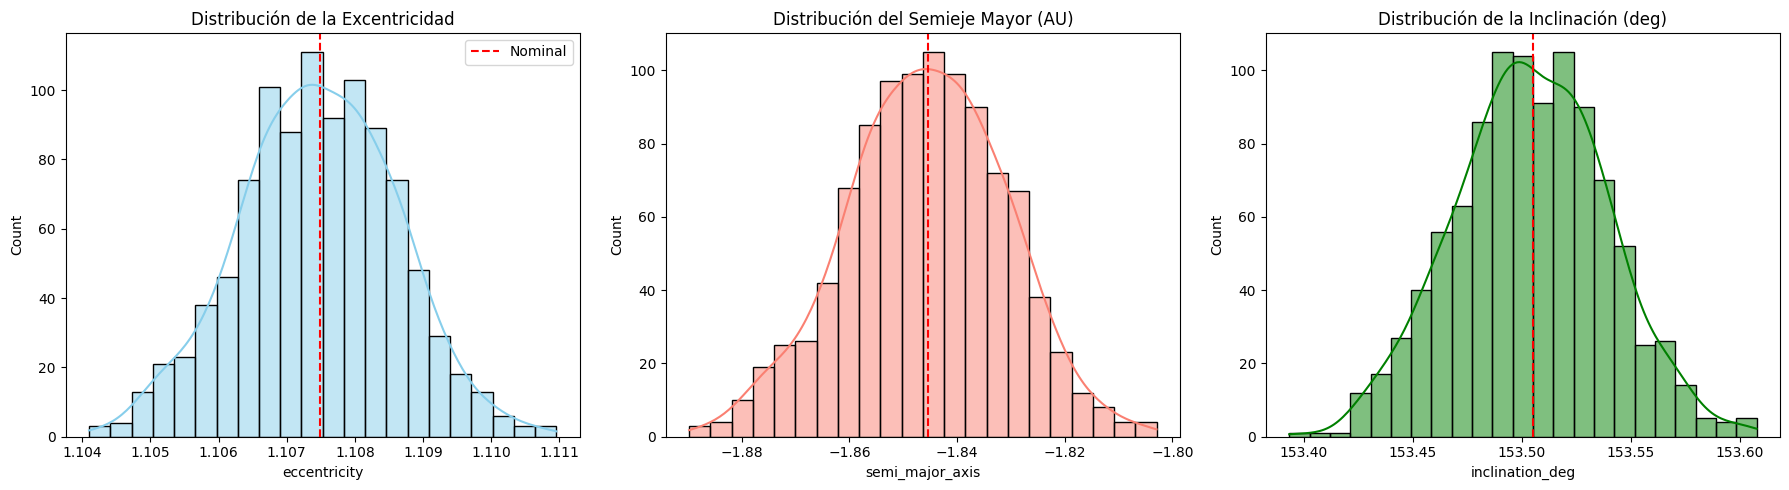

In [43]:
import seaborn as sns

# Visualización de las distribuciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma de Excentricidad
sns.histplot(df_mc['eccentricity'], kde=True, ax=axes[0], color='skyblue')
axes[0].axvline(elementos['eccentricity'], color='red', linestyle='--', label='Nominal')
axes[0].set_title('Distribución de la Excentricidad')
axes[0].legend()

# Histograma del Semieje Mayor (usamos log scale o filtramos outliers si es necesario)
sns.histplot(df_mc['semi_major_axis'], kde=True, ax=axes[1], color='salmon')
axes[1].axvline(elementos['semi_major_axis'], color='red', linestyle='--')
axes[1].set_title('Distribución del Semieje Mayor (AU)')

# Histograma de la Inclinación
sns.histplot(df_mc['inclination_deg'], kde=True, ax=axes[2], color='green')
axes[2].axvline(elementos['inclination_deg'], color='red', linestyle='--')
axes[2].set_title('Distribución de la Inclinación (deg)')

plt.tight_layout()
plt.show()


In [44]:

# Resumen de dispersión
print(f"Incertidumbre en e: {df_mc['eccentricity'].std():.6f}")
print(f"Incertidumbre en i: {df_mc['inclination_deg'].std():.6f} grados")

Incertidumbre en e: 0.001149
Incertidumbre en i: 0.034647 grados


## Evolución temporal de la órbita
Con los elementos orbitales se puede propagar la posición del cuerpo en el tiempo. Esta parte
responde una pregunta distinta a la de la forma de la órbita: no basta con saber qué cónica es;
también necesitamos saber cómo se recorre.

## Partir de los elementos orbitales de la órbita inicial

In [45]:
def propagar(elementos, t_target, mu=0.0002959122082855911):
    """
    Propaga la posición del objeto a un tiempo t_target dado sus elementos orbitales.
    """
    e = elementos['eccentricity']
    a = elementos['semi_major_axis']
    i = np.radians(elementos['inclination_deg'])
    Omega = np.radians(elementos['ascending_node_deg'])
    omega = np.radians(elementos['arg_perihelion_deg'])
    f0 = np.radians(elementos['true_anomaly_deg'])
    t0 = elementos['epoch']

    dt = t_target - t0
    n = np.sqrt(mu / abs(a)**3)

    if e > 1: # Caso Hiperbólico
        # 1. Hallar H0 a partir de f0
        H0 = 2 * np.arctanh(np.sqrt((e - 1)/(e + 1)) * np.tan(f0 / 2))
        # 2. Hallar Mh en t_target
        Mh0 = e * np.sinh(H0) - H0
        Mh_t = Mh0 + n * dt

        # 3. Resolver Mh = e*sinh(H) - H para H usando Newton-Raphson
        H = Mh_t # Semilla inicial
        for _ in range(10):
            f = e * np.sinh(H) - H - Mh_t
            fp = e * np.cosh(H) - 1
            H = H - f / fp

        # 4. Obtener f_t
        f_t = 2 * np.arctan(np.sqrt((e + 1)/(e - 1)) * np.tanh(H / 2))
        r_mag = abs(a) * (e * np.cosh(H) - 1)

    else: # Caso Elíptico
        E0 = 2 * np.arctan(np.sqrt((1 - e)/(1 + e)) * np.tan(f0 / 2))
        M0 = E0 - e * np.sin(E0)
        M_t = (M0 + n * dt) % (2 * np.pi)

        E = M_t
        for _ in range(10):
            f = E - e * np.sin(E) - M_t
            fp = 1 - e * np.cos(E)
            E = E - f / fp

        f_t = 2 * np.arctan(np.sqrt((1 + e)/(1 - e)) * np.tan(E / 2))
        r_mag = a * (1 - e * np.cos(E))

    # 5. Posición en el plano orbital (perifocal)
    r_perifocal = np.array([
        r_mag * np.cos(f_t),
        r_mag * np.sin(f_t),
        0
    ])

    # 6. Matrices de rotación para pasar a coordenadas heliocéntricas
    def Rz(theta):
        return np.array([[np.cos(theta), -np.sin(theta), 0], [np.sin(theta), np.cos(theta), 0], [0, 0, 1]])
    def Rx(theta):
        return np.array([[1, 0, 0], [0, np.cos(theta), -np.sin(theta)], [0, np.sin(theta), np.cos(theta)]])

    # r_helio = Rz(Omega) * Rx(i) * Rz(omega) * r_perifocal
    rot_matrix = Rz(Omega) @ Rx(i) @ Rz(omega)
    r_helio = rot_matrix @ r_perifocal

    return r_helio

# Ejemplo: Propagar 10 días al futuro
t_futuro = epoch_target + 10
r_futuro = propagar(elementos, t_futuro)
print(f"Posición predicha para JD {t_futuro} ({t_futuro - epoch_target} días en el futuro): {r_futuro} AU")

Posición predicha para JD 2451554.5 (10.0 días en el futuro): [1.6308946  0.57829718 0.10125519] AU


## Máxima Proximidad de la Tierra

In [55]:
# Extraer la distancia Tierra-Objeto (rho) del dataset filtrado
distancias_tierra = df_target[['datetime_utc', 'rho_au']].copy()
distancias_tierra.columns = ['Fecha UTC', 'Distancia (AU)']

print(f"Distancias calculadas para {target_object} respecto a la Tierra:")
display(distancias_tierra.head())

# Distancia mínima observada en este periodo
min_dist = df_target['rho_au'].min()
fecha_min = df_target.loc[df_target['rho_au'].idxmin(), 'datetime_utc']

print(f"\nLa distancia mínima observada fue de {min_dist:.4f} AU el {fecha_min}.")

Distancias calculadas para oumuamua respecto a la Tierra:


,Fecha UTC,Distancia (AU)
0,2017-10-19 23:58:50.818,0.245243
1,2017-10-20 23:58:50.818,0.272808
2,2017-10-21 23:58:50.818,0.302073
3,2017-10-22 23:58:50.818,0.332618
4,2017-10-23 23:58:50.818,0.364148



La distancia mínima observada fue de 0.2452 AU el 2017-10-19 23:58:50.818.


In [59]:
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

# 1. Aseguramos que los elementos nominales correspondan a la época de las observaciones
# Recalculamos usando r0_obj y v0_obj definidos anteriormente para la época de 2017
elementos_obs = calculate_orbital_elements(r0_obj, v0_obj, df_target.iloc[idx_target]['t_jd_tdb'])

# 2. Crear interpoladores para la posición de la Tierra usando los datos del CSV
t_obs = df_target['t_jd_tdb'].values
earth_pos_data = df_target[['earth_x_au', 'earth_y_au', 'earth_z_au']].values
get_earth_pos = interp1d(t_obs, earth_pos_data, axis=0, kind='cubic', fill_value='extrapolate')

def distance_to_earth(t, orbit_elements):
    """Calcula la distancia entre el objeto y la Tierra en el tiempo t."""
    r_obj = propagar(orbit_elements, t)
    r_earth = get_earth_pos(t)
    return np.linalg.norm(r_obj - r_earth)

# 3. Encontrar el mínimo nominal con los elementos corregidos
res_min = minimize_scalar(distance_to_earth, bounds=(t_obs.min(), t_obs.max()), args=(elementos_obs,), method='bounded')

t_min_nominal = res_min.x
d_min_nominal = res_min.fun

print(f"Encuentro cercano NOMINAL (Corregido):")
print(f"Fecha (JD): {t_min_nominal:.4f}")
print(f"Distancia mínima: {d_min_nominal:.6f} AU")

Encuentro cercano NOMINAL (Corregido):
Fecha (JD): 2458046.5714
Distancia mínima: 0.247048 AU


Calculando distribución de encuentros cercanos con Monte Carlo...


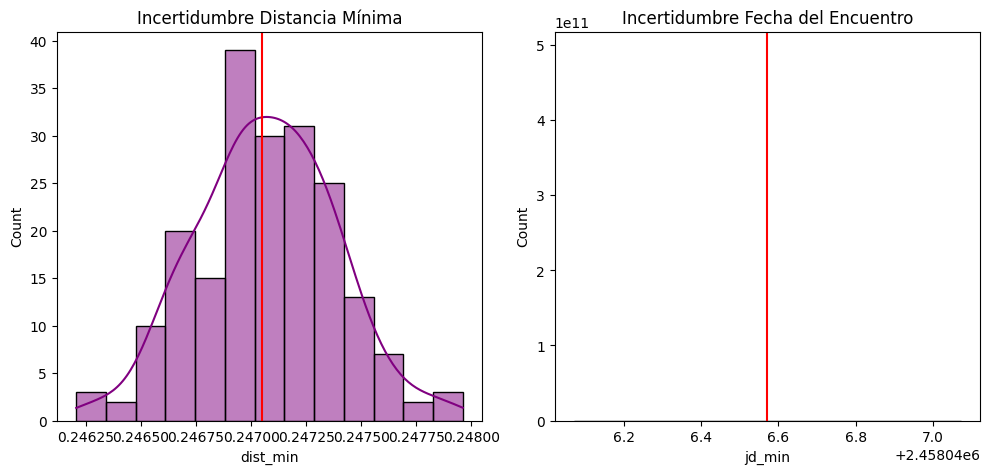

In [60]:
# 3. Análisis de Incertidumbre (Monte Carlo)
print("Calculando distribución de encuentros cercanos con Monte Carlo...")
mc_encuentros = []

# Usamos una submuestra para velocidad (ej. 200 iteraciones)
for i in range(200):
    orbita_i = mc_results[i]
    res = minimize_scalar(distance_to_earth, bounds=(t_obs.min(), t_obs.max()), args=(orbita_i,), method='bounded')
    mc_encuentros.append({'jd_min': res.x, 'dist_min': res.fun})

df_encuentros = pd.DataFrame(mc_encuentros)

# Visualización
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_encuentros['dist_min'], kde=True, color='purple')
plt.axvline(d_min_nominal, color='red', label='Nominal')
plt.title('Incertidumbre Distancia Mínima')

plt.subplot(1, 2, 2)
sns.histplot(df_encuentros['jd_min'], kde=True, color='orange')
plt.axvline(t_min_nominal, color='red')
plt.title('Incertidumbre Fecha del Encuentro')
plt.tight_layout()
plt.show()

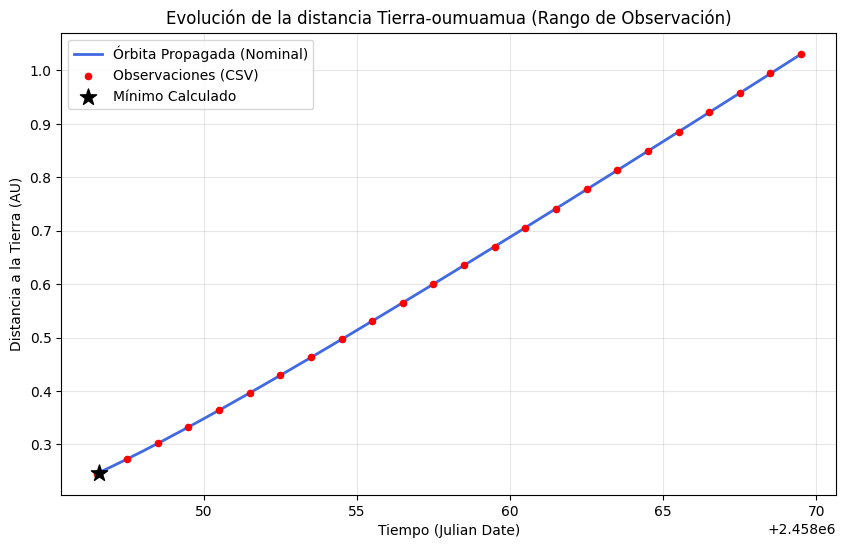

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear un eje de tiempo continuo (JD) desde la primera observación hasta la última
t_vector = np.linspace(df_target['t_jd_tdb'].min(), df_target['t_jd_tdb'].max(), 500)

# 2. Calcular la distancia para cada punto en el tiempo
distancias_modelo = [distance_to_earth(t, elementos_obs) for t in t_vector]

# 3. Graficar
plt.figure(figsize=(10, 6))
plt.plot(t_vector, distancias_modelo, label='Órbita Propagada (Nominal)', color='royalblue', linewidth=2)
plt.scatter(df_target['t_jd_tdb'], df_target['rho_au'], color='red', s=20, label='Observaciones (CSV)', zorder=3)

# Resaltar el punto de máxima proximidad nominal encontrado por el optimizador
plt.scatter(t_min_nominal, d_min_nominal, color='black', marker='*', s=150, label='Mínimo Calculado', zorder=4)

plt.xlabel('Tiempo (Julian Date)')
plt.ylabel('Distancia a la Tierra (AU)')
plt.title(f'Evolución de la distancia Tierra-{target_object} (Rango de Observación)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [63]:
from pymcel import plot_ncuerpos_3d

# 1. Definir el vector de tiempo continuo (JD)
t_plot = np.linspace(df_target['t_jd_tdb'].min(), df_target['t_jd_tdb'].max(), 300)

# 2. Obtener trayectorias
# Sol: siempre en el origen
pos_sun = np.zeros((len(t_plot), 3))
# Tierra: usando nuestro interpolador de los datos del CSV
pos_earth = np.array([get_earth_pos(t) for t in t_plot])
# Oumuamua: usando el propagador orbital
pos_oumuamua = np.array([propagar(elementos_obs, t) for t in t_plot])

# 3. Empaquetar los datos en el formato que requiere plot_ncuerpos_3d
# rs debe ser (N_cuerpos, N_tiempos, 3)
rs = np.stack([pos_sun, pos_earth, pos_oumuamua])

# vs no son estrictamente necesarios para el plot pero se pasan como ceros o se omiten si es posible
vs = np.zeros_like(rs)

# 4. Graficar
fig = plot_ncuerpos_3d(
    rs,
    vs,
    tipo='plotly',
    nombres=['Sol', 'Tierra', f'Objeto: {target_object}']
)

fig.update_layout(title=f'Trayectoria 3D Heliocéntrica de {target_object}')
fig.show()